Instalación y carga

In [1]:
!pip install rdflib nltk pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 13.9 MB/s eta 0:00:00


In [2]:
import nltk
import pandas as pd

from rdflib import Graph, RDF, RDFS, OWL
from nltk.corpus import wordnet

In [3]:
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("extended_omw")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package extended_omw to /root/nltk_data...


True

In [4]:
from google.colab import files

uploaded = files.upload()

Leer el archivo OWL generado por Protegé

In [5]:
g = Graph()

g.parse("ontologia_ciclo_conflicto_base.owl", format="xml")

print("Tripletas:", len(g))

Tripletas: 9973


Extraer las clases ontológicas

Obtener nombre de cada clase

In [6]:
def get_local_name(uri):
    uri = str(uri)

    if "#" in uri:
        return uri.split("#")[-1]

    return uri.rstrip("/").split("/")[-1]

In [7]:
classes = []

for cls in g.subjects(RDF.type, OWL.Class):

    uri = str(cls)

    label = g.value(
        cls,
        RDFS.label
    )

    classes.append({
        "owl_uri": uri,
        "owl_concept": get_local_name(uri),
        "label": str(label) if label else None
    })

print("Número de clases:", len(classes))

Número de clases: 2968


In [8]:
print(classes[:90])

[{'owl_uri': 'http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#EstructuraArmada', 'owl_concept': 'EstructuraArmada', 'label': 'Estructuras armadas'}, {'owl_uri': 'http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#Hecho_victimizante', 'owl_concept': 'Hecho_victimizante', 'label': 'Hecho victimizante'}, {'owl_uri': 'http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#Arma', 'owl_concept': 'Arma', 'label': 'Armas'}, {'owl_uri': 'http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#ProfesionOficio', 'owl_concept': 'ProfesionOficio', 'label': 'Profesiones y oficios'}, {'owl_uri': 'http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#PartidosYMovimientosPoliticos', 'owl_concept': 'PartidosYMovimientosPoliticos', 'label': 'Partidos y movimientos políticos'}, {'owl_uri': 'http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#APILAS', 'owl_concept': 'APILAS', 'label': 'APILAS'}, {'owl_uri': 'http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#Misil_antitanqueta', 'owl_conc

Normalizar nombres

In [9]:
import re

def normalize_term(term):
    """
    Normaliza el nombre de una clase de la ontología para
    poder utilizarlo como término de búsqueda en WordNet.
    """

    # Convertir URI/local name a string
    term = str(term).strip()

    # Separar palabras escritas en CamelCase
    term = re.sub(
        r'(?<=[a-záéíóúñ])(?=[A-ZÁÉÍÓÚÑ])',
        ' ',
        term
    )

    # Separar secuencias como XMLParser -> XML Parser
    term = re.sub(
        r'(?<=[A-ZÁÉÍÓÚÑ])(?=[A-ZÁÉÍÓÚÑ][a-záéíóúñ])',
        ' ',
        term
    )

    # Reemplazar guiones bajos y guiones
    term = term.replace("_", " ")
    term = term.replace("-", " ")

    # Convertir a minúsculas
    term = term.lower()

    # Eliminar espacios duplicados
    term = re.sub(r'\s+', ' ', term).strip()

    return term

In [10]:
def get_synsets(term):
    """
    Busca un término en WordNet en español.

    Prueba:
    1. El término con espacios.
    2. El término con guiones bajos.

    Retorna:
    - synsets encontrados
    - forma utilizada para la búsqueda
    """

    term = normalize_term(term)

    # Formas posibles de búsqueda
    search_terms = [term]

    if " " in term:
        search_terms.append(term.replace(" ", "_"))

    for search_term in search_terms:

        synsets = wordnet.synsets(
            search_term,
            lang="spa"
        )

        if synsets:
            return synsets, search_term

    return [], None

In [11]:
def get_candidate_synsets(term):
    """
    Obtiene los synsets candidatos de WordNet para un término.

    Prueba:
    - término normalizado
    - término con espacios reemplazados por "_"

    Retorna una lista de tuplas:
    (synset, search_term)
    """

    term = normalize_term(term)

    search_terms = [term]

    if " " in term:
        search_terms.append(term.replace(" ", "_"))

    candidates = []

    for search_term in search_terms:

        synsets = wordnet.synsets(
            search_term,
            lang="spa"
        )

        for syn in synsets:

            candidates.append(
                (syn, search_term)
            )

    # Eliminar duplicados
    unique_candidates = {}

    for syn, search_term in candidates:

        key = syn.name()

        if key not in unique_candidates:
            unique_candidates[key] = (
                syn,
                search_term
            )

    return list(unique_candidates.values())

In [20]:
concept_data = []

for concept in classes:

    synsets, search_term = get_synsets(concept["label"])

    if(len(synsets) > 0):
      print("=" * 60)
      print("Término:", search_term)
      print("Búsqueda utilizada:", search_term)
      print("Synsets encontrados:", len(synsets))
    concept_data.append({
        "owl_concept": concept["owl_concept"],
        "owl_uri" : concept["owl_uri"],
        "label" : concept["label"],
        "search_term": search_term,
        "wordnet_found": len(synsets) > 0,
        "num_synsets": len(synsets),
        "synsets": synsets
    })

concepts_df = pd.DataFrame(concept_data)

Término: acoso_sexual
Búsqueda utilizada: acoso_sexual
Synsets encontrados: 1
Término: batallón
Búsqueda utilizada: batallón
Synsets encontrados: 1
Término: unidad_militar
Búsqueda utilizada: unidad_militar
Synsets encontrados: 1
Término: unidad
Búsqueda utilizada: unidad
Synsets encontrados: 11
Término: brigada
Búsqueda utilizada: brigada
Synsets encontrados: 1
Término: división
Búsqueda utilizada: división
Synsets encontrados: 9
Término: compañía
Búsqueda utilizada: compañía
Synsets encontrados: 5
Término: cordillera
Búsqueda utilizada: cordillera
Synsets encontrados: 1
Término: cuchillo
Búsqueda utilizada: cuchillo
Synsets encontrados: 2
Término: democracia
Búsqueda utilizada: democracia
Synsets encontrados: 2
Término: homicidio
Búsqueda utilizada: homicidio
Synsets encontrados: 1
Término: espada
Búsqueda utilizada: espada
Synsets encontrados: 2
Término: exilio
Búsqueda utilizada: exilio
Synsets encontrados: 1
Término: medios
Búsqueda utilizada: medios
Synsets encontrados: 1
Término

In [21]:
concepts_df.head()

,owl_concept,owl_uri,label,search_term,wordnet_found,num_synsets,synsets
0,EstructuraArmada,http://www.semanticweb.org/tesauro-cev-ciclo-c...,Estructuras armadas,None,False,0,[]
1,Hecho_victimizante,http://www.semanticweb.org/tesauro-cev-ciclo-c...,Hecho victimizante,None,False,0,[]
2,Arma,http://www.semanticweb.org/tesauro-cev-ciclo-c...,Armas,None,False,0,[]
3,ProfesionOficio,http://www.semanticweb.org/tesauro-cev-ciclo-c...,Profesiones y oficios,None,False,0,[]
4,PartidosYMovimientosPoliticos,http://www.semanticweb.org/tesauro-cev-ciclo-c...,Partidos y movimientos políticos,None,False,0,[]


In [22]:
concepts_with_synsets = [
    item for item in concept_data
    if item["synsets"]
]

print(len(concepts_df))
print(len(concepts_with_synsets))


2968
189


In [23]:
concepts_with_synsets = concepts_df[
    concepts_df["wordnet_found"] == True
].copy()

print("Conceptos encontrados:", len(concepts_with_synsets))

Conceptos encontrados: 189


In [24]:
concepts_with_synsets[
    ["label", "num_synsets"]
].sort_values(
    "num_synsets",
    ascending=False
).head(20)

,label,num_synsets
360,Unidad,11
399,División,9
2180,Director,9
2387,Profesional,9
2058,Agente,8
2458,Trabajador,8
2465,Técnico,7
2212,Escolta,6
2332,Médico,6
2273,Jefe,6


In [28]:
def synset_terms(syn):
    """
    Obtiene los términos disponibles en español
    para un synset.
    """

    return syn.lemma_names(lang="spa")

In [29]:
def add_relation(
    relations,
    source_syn,
    relation_type,
    target_syn
):

    relations.append({
        "relation": relation_type,
        "source_synset": source_syn.name(),
        "source_definition": source_syn.definition(),
        "target_synset": target_syn.name(),
        "target_terms": synset_terms(target_syn),
        "target_definition": target_syn.definition()
    })

In [49]:
def get_wordnet_relations(syn):

    relations = []

    # ==========================================================
    # 1. SINONIMIA
    # ==========================================================

    spanish_lemmas = syn.lemma_names(lang="spa")

    if spanish_lemmas:

        relations.append({
            "relation": "synonymy",
            "source_synset": syn.name(),
            "source_definition": syn.definition(),
            "target_synset": syn.name(),
            "target_terms": spanish_lemmas,
            "target_definition": syn.definition()
        })

    # ==========================================================
    # 2. ANTONIMIA
    # ==========================================================

    for lemma in syn.lemmas(lang="spa"):

        for antonym in lemma.antonyms():

            relations.append({
                "relation": "antonymy",
                "source_synset": syn.name(),
                "source_definition": syn.definition(),
                "target_synset": antonym.synset().name(),
                "target_terms": [antonym.name()],
                "target_definition": antonym.synset().definition()
            })

    # ==========================================================
    # 3. HIPERONIMIA
    # ==========================================================

    for hyper in syn.hypernyms():

        add_relation(
            relations,
            syn,
            "hypernymy",
            hyper
        )

    # ==========================================================
    # 4. HIPONIMIA
    # ==========================================================

    for hypo in syn.hyponyms():

        add_relation(
            relations,
            syn,
            "hyponymy",
            hypo
        )

    # ==========================================================
    # 5. MERONIMIA
    # ==========================================================

    meronyms = (
        syn.part_meronyms()
        + syn.substance_meronyms()
        + syn.member_meronyms()
    )

    for mero in meronyms:

        add_relation(
            relations,
            syn,
            "meronymy",
            mero
        )

    # ==========================================================
    # 6. HOLONIMIA
    # ==========================================================

    holonyms = (
        syn.part_holonyms()
        + syn.substance_holonyms()
        + syn.member_holonyms()
    )

    for holo in holonyms:

        add_relation(
            relations,
            syn,
            "holonymy",
            holo
        )

    # ==========================================================
    # 7. TROPONIMIA
    # ==========================================================

    if syn.pos() == "v":

        for tropo in syn.hyponyms():

            add_relation(
                relations,
                syn,
                "troponymy",
                tropo
            )

    # ==========================================================
    # 8. TÉRMINOS COORDINADOS
    # ==========================================================

    for hyper in syn.hypernyms():

        for sibling in hyper.hyponyms():

            if sibling != syn:

                add_relation(
                    relations,
                    syn,
                    "coordinate_term",
                    sibling
                )

    # ==========================================================
    # 9. DERIVACIÓN MORFOLÓGICA
    # ==========================================================

    for lemma in syn.lemmas(lang="spa"):

        for related in lemma.derivationally_related_forms():

            relations.append({
                "relation": "derivational_form",
                "source_synset": syn.name(),
                "source_definition": syn.definition(),
                "target_synset": related.synset().name(),
                "target_terms": [related.name()],
                "target_definition": related.synset().definition()
            })

    return relations

In [35]:
verb_concepts = []

for _, row in concepts_with_synsets.iterrows():

    for syn in row["synsets"]:

        if syn.pos() == "v":

            verb_concepts.append({
                "owl_concept": row["owl_concept"],
                "synset": syn.name(),
                "definition": syn.definition()
            })

verb_concepts_df = pd.DataFrame(verb_concepts)
print(len(verb_concepts_df))
verb_concepts_df.head(1000)

2


,owl_concept,synset,definition
0,Mensajero,page.v.02,work as a page
1,Presidente,chair.v.01,"act or preside as chair, as of an academic dep..."


In [39]:
synset_data = []

for _, row in concepts_with_synsets.iterrows():

    for syn in row["synsets"]:

        synset_data.append({
            "owl_concept": row["owl_concept"],
            "label": row["label"],
            "synset": syn.name(),
            "definition": syn.definition(),
            "lemmas": syn.lemma_names(lang="spa"),
            "relations": get_wordnet_relations(syn)
        })

synsets_df = pd.DataFrame(synset_data)

In [43]:
print(len(synsets_df))
synsets_df.head(20)

414


,owl_concept,label,synset,definition,lemmas,relations
0,Acoso_sexual,Acoso sexual,sexual_harassment.n.01,unwelcome sexual behavior by a supervisor towa...,[acoso_sexual],"[{'relation': 'synonymy', 'source_synset': 'se..."
1,Batallon,Batallón,battalion.n.02,a large indefinite number,"[batallón, ejército, masa, multitud]","[{'relation': 'synonymy', 'source_synset': 'ba..."
2,Unidad_militar,Unidad militar,military_unit.n.01,a unit that is part of some military service,"[unidad, unidad_militar]","[{'relation': 'synonymy', 'source_synset': 'mi..."
3,Unidad,Unidad,whole.n.02,an assemblage of parts that is regarded as a s...,"[conjunto, unidad, unidad_completa]","[{'relation': 'synonymy', 'source_synset': 'wh..."
4,Unidad,Unidad,drive.n.10,(computer science) a device that writes data o...,[unidad],"[{'relation': 'synonymy', 'source_synset': 'dr..."
5,Unidad,Unidad,system.n.01,instrumentality that combines interrelated int...,"[sistema, unidad]","[{'relation': 'synonymy', 'source_synset': 'sy..."
6,Unidad,Unidad,oneness.n.01,the quality of being united into one,[unidad],"[{'relation': 'synonymy', 'source_synset': 'on..."
7,Unidad,Unidad,unit.n.04,a single undivided whole,[unidad],"[{'relation': 'synonymy', 'source_synset': 'un..."
8,Unidad,Unidad,unit.n.03,an organization regarded as part of a larger s...,"[sección, unidad]","[{'relation': 'synonymy', 'source_synset': 'un..."
9,Unidad,Unidad,military_unit.n.01,a unit that is part of some military service,"[unidad, unidad_militar]","[{'relation': 'synonymy', 'source_synset': 'mi..."


In [42]:
relations_data = []

for _, row in synsets_df.iterrows():

    for relation in row["relations"]:

        relations_data.append({
            "owl_concept": row["owl_concept"],
            "label": row["label"],
            "source_synset": relation["source_synset"],
            "relation": relation["relation"],
            "target_synset": relation["target_synset"],
            "target_terms": ", ".join(relation["target_terms"]),
            "source_definition": relation["source_definition"],
            "target_definition": relation["target_definition"]
        })

relations_df = pd.DataFrame(relations_data)

relations_df.head(20)

,owl_concept,label,source_synset,relation,target_synset,target_terms,source_definition,target_definition
0,Acoso_sexual,Acoso sexual,sexual_harassment.n.01,synonymy,sexual_harassment.n.01,acoso_sexual,unwelcome sexual behavior by a supervisor towa...,unwelcome sexual behavior by a supervisor towa...
1,Acoso_sexual,Acoso sexual,sexual_harassment.n.01,hypernymy,harassment.n.02,,unwelcome sexual behavior by a supervisor towa...,the act of tormenting by continued persistent ...
2,Acoso_sexual,Acoso sexual,sexual_harassment.n.01,coordinate_term,witch-hunt.n.01,caza_de_brujas,unwelcome sexual behavior by a supervisor towa...,searching out and harassing dissenters
3,Acoso_sexual,Acoso sexual,sexual_harassment.n.01,coordinate_term,baiting.n.01,,unwelcome sexual behavior by a supervisor towa...,harassment especially of a tethered animal
4,Acoso_sexual,Acoso sexual,sexual_harassment.n.01,coordinate_term,badgering.n.01,,unwelcome sexual behavior by a supervisor towa...,the act of harassing someone
5,Acoso_sexual,Acoso sexual,sexual_harassment.n.01,coordinate_term,tease.n.03,,unwelcome sexual behavior by a supervisor towa...,the act of harassing someone playfully or mali...
6,Batallon,Batallón,battalion.n.02,synonymy,battalion.n.02,"batallón, ejército, masa, multitud",a large indefinite number,a large indefinite number
7,Batallon,Batallón,battalion.n.02,synonymy,battalion.n.02,"batallón, ejército, masa, multitud",a large indefinite number,a large indefinite number
8,Batallon,Batallón,battalion.n.02,synonymy,battalion.n.02,"batallón, ejército, masa, multitud",a large indefinite number,a large indefinite number
9,Batallon,Batallón,battalion.n.02,synonymy,battalion.n.02,"batallón, ejército, masa, multitud",a large indefinite number,a large indefinite number


In [44]:
simple_relations_df = relations_df[
    [
        "owl_concept",
        "label",
        "relation",
        "target_synset",
        "target_terms"
    ]
].copy()

simple_relations_df

,owl_concept,label,relation,target_synset,target_terms
0,Acoso_sexual,Acoso sexual,synonymy,sexual_harassment.n.01,acoso_sexual
1,Acoso_sexual,Acoso sexual,hypernymy,harassment.n.02,
2,Acoso_sexual,Acoso sexual,coordinate_term,witch-hunt.n.01,caza_de_brujas
3,Acoso_sexual,Acoso sexual,coordinate_term,baiting.n.01,
4,Acoso_sexual,Acoso sexual,coordinate_term,badgering.n.01,
...,...,...,...,...,...
12261,Gobernador,Gobernador,coordinate_term,passer.n.02,
12262,Gobernador,Gobernador,coordinate_term,beard.n.03,
12263,Gobernador,Gobernador,coordinate_term,endomorph.n.01,
12264,Gobernador,Gobernador,coordinate_term,ethnic.n.01,


In [45]:
relation_summary = (
    relations_df
    .groupby(["label", "relation"])
    .size()
    .reset_index(name="count")
)

relation_summary

,label,relation,count
0,Abogado,coordinate_term,9
1,Abogado,holonymy,1
2,Abogado,hypernymy,1
3,Abogado,hyponymy,11
4,Abogado,synonymy,4
...,...,...,...
731,Vocero,hyponymy,4
732,Vocero,synonymy,2
733,Yesero,coordinate_term,64
734,Yesero,hypernymy,1


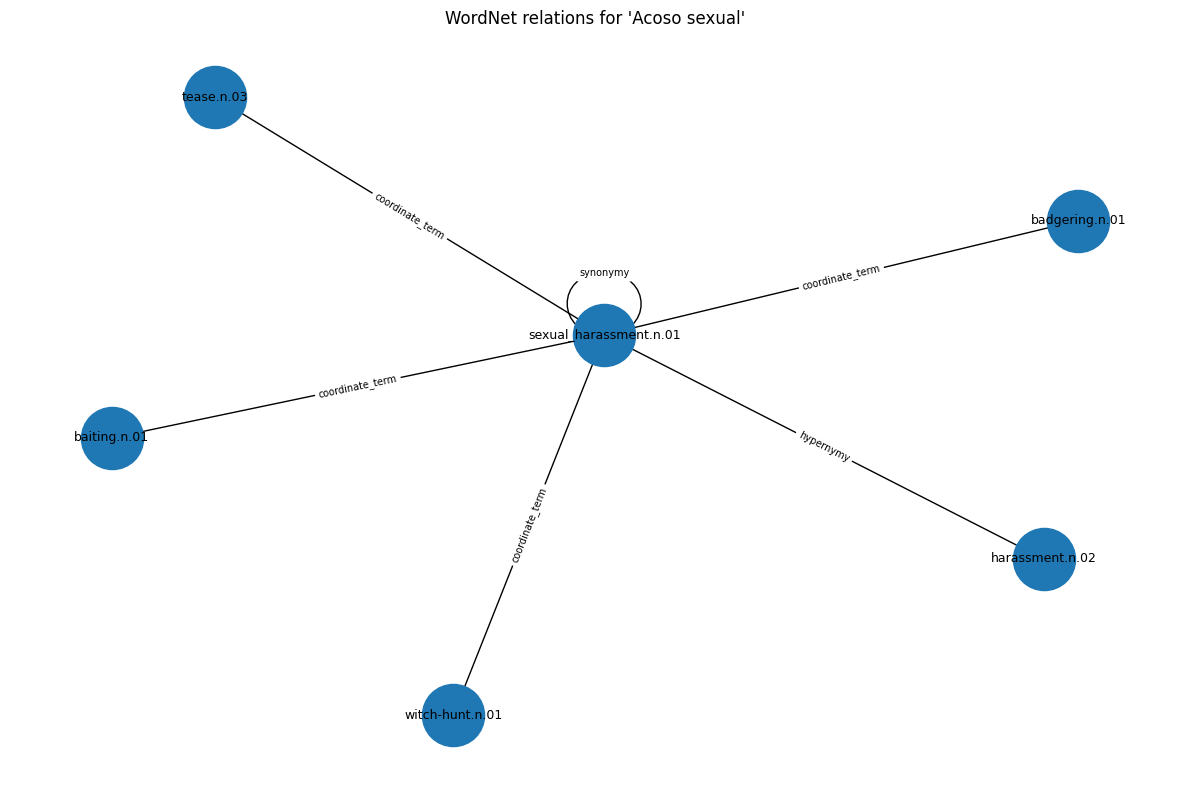

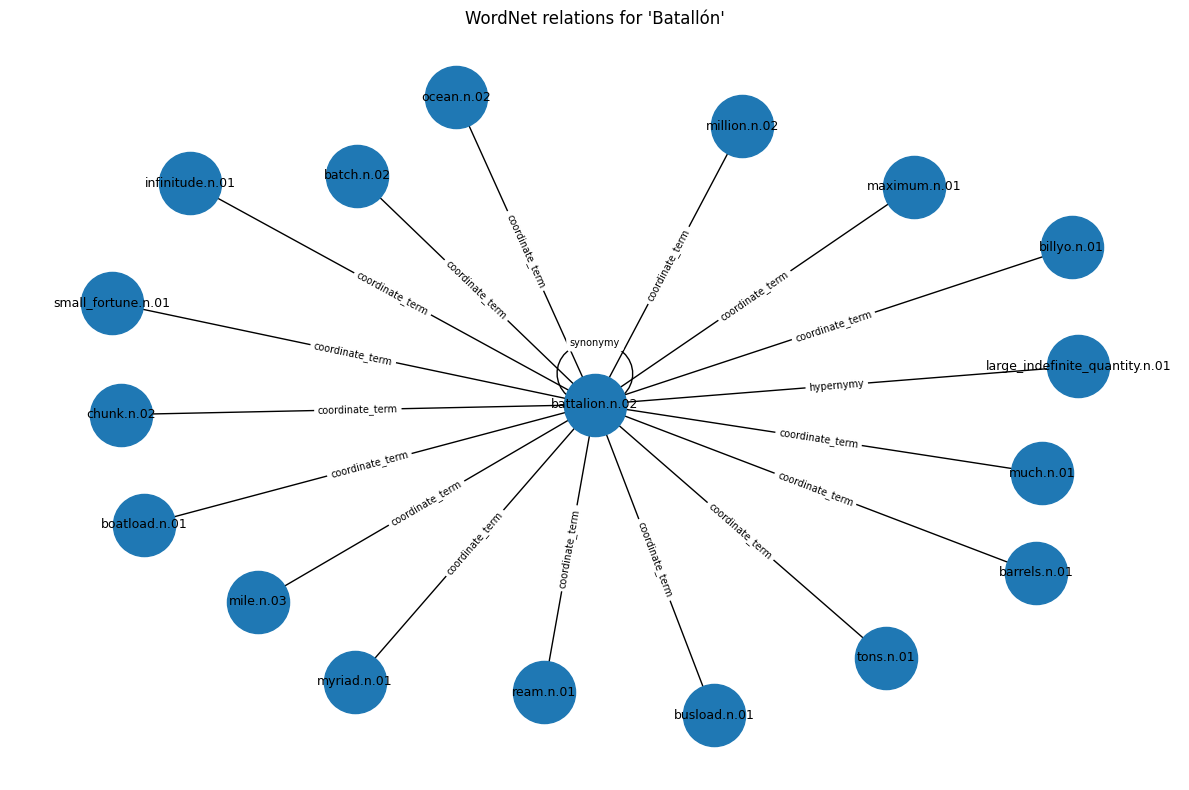

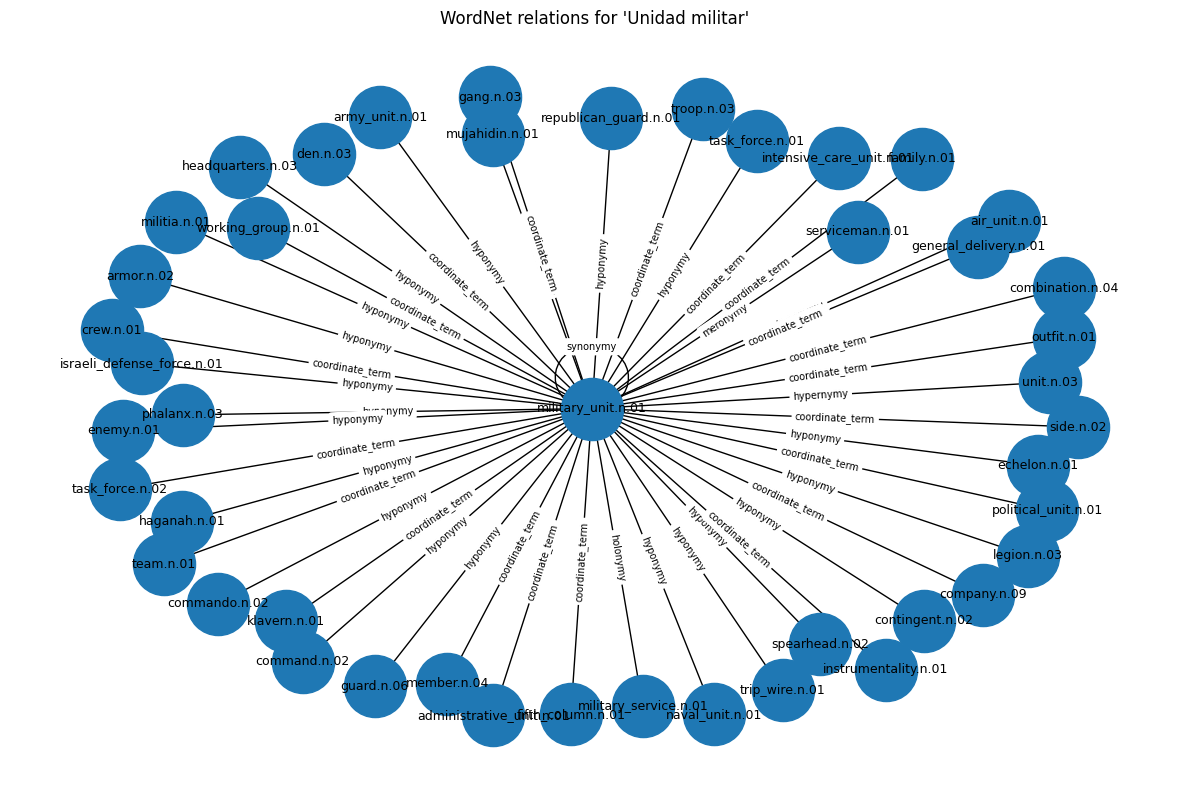

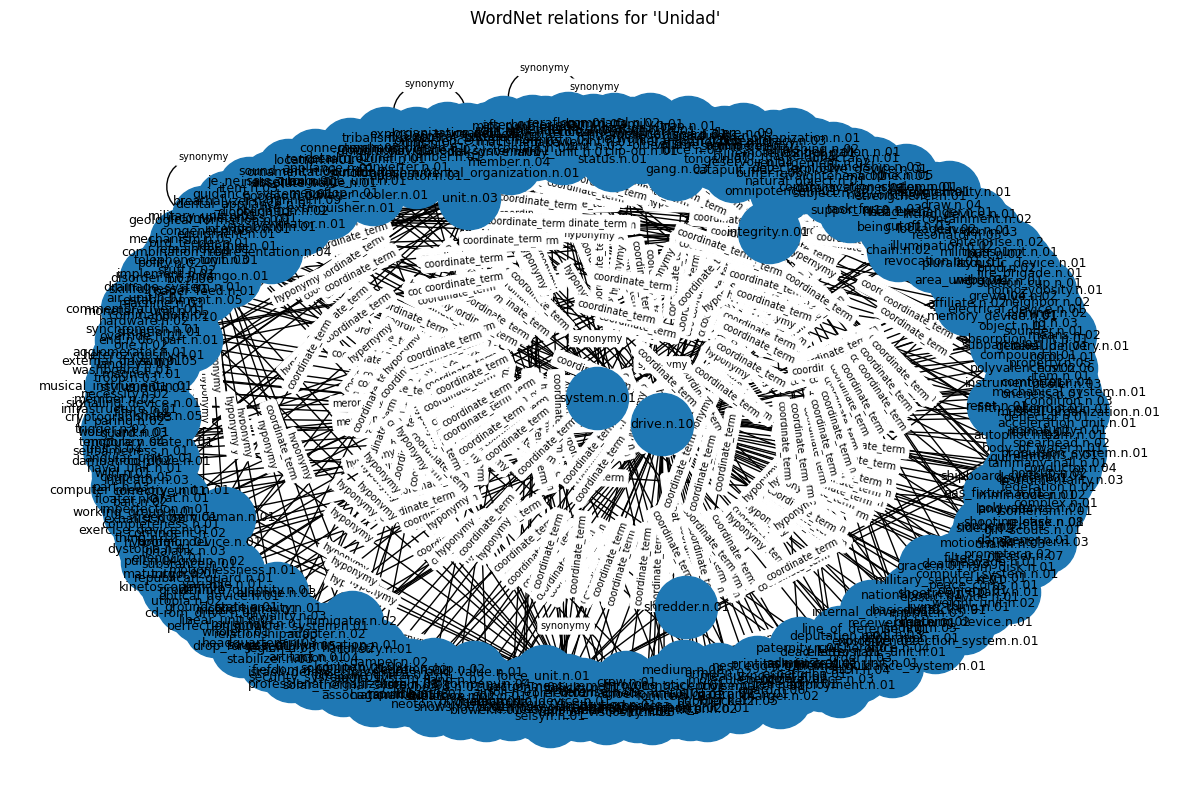

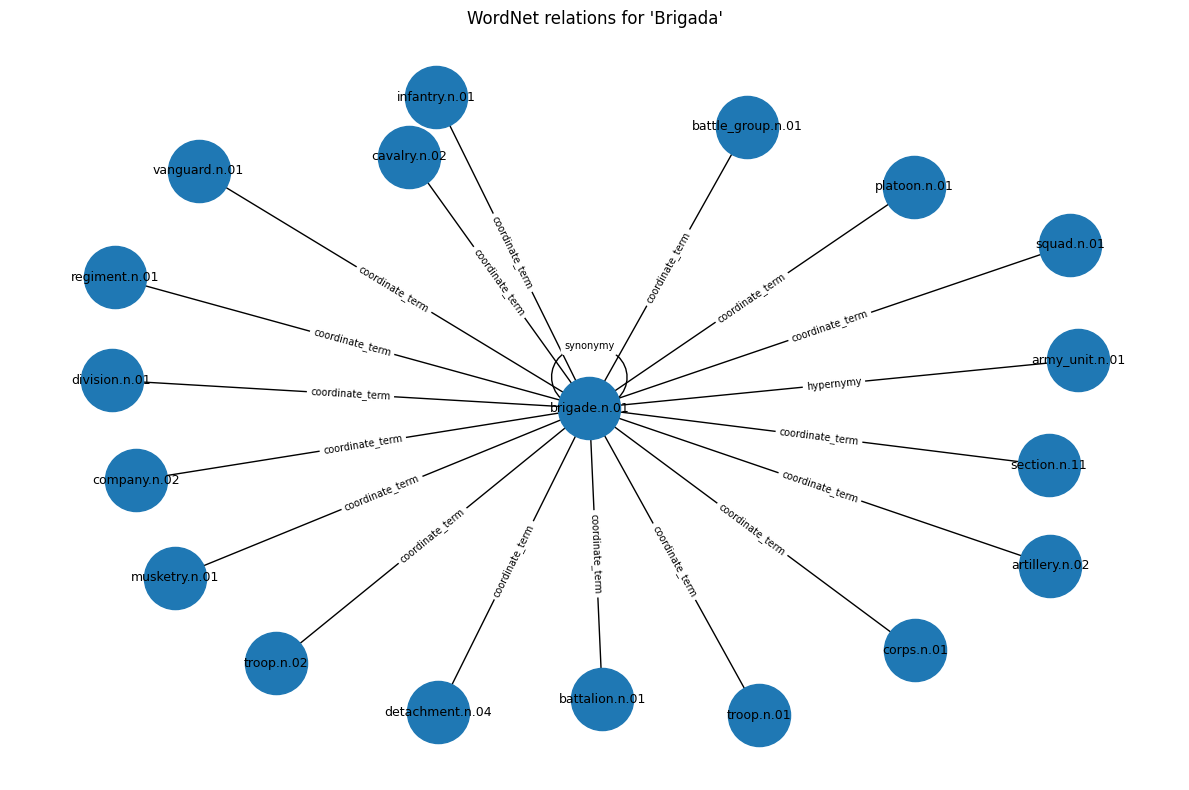

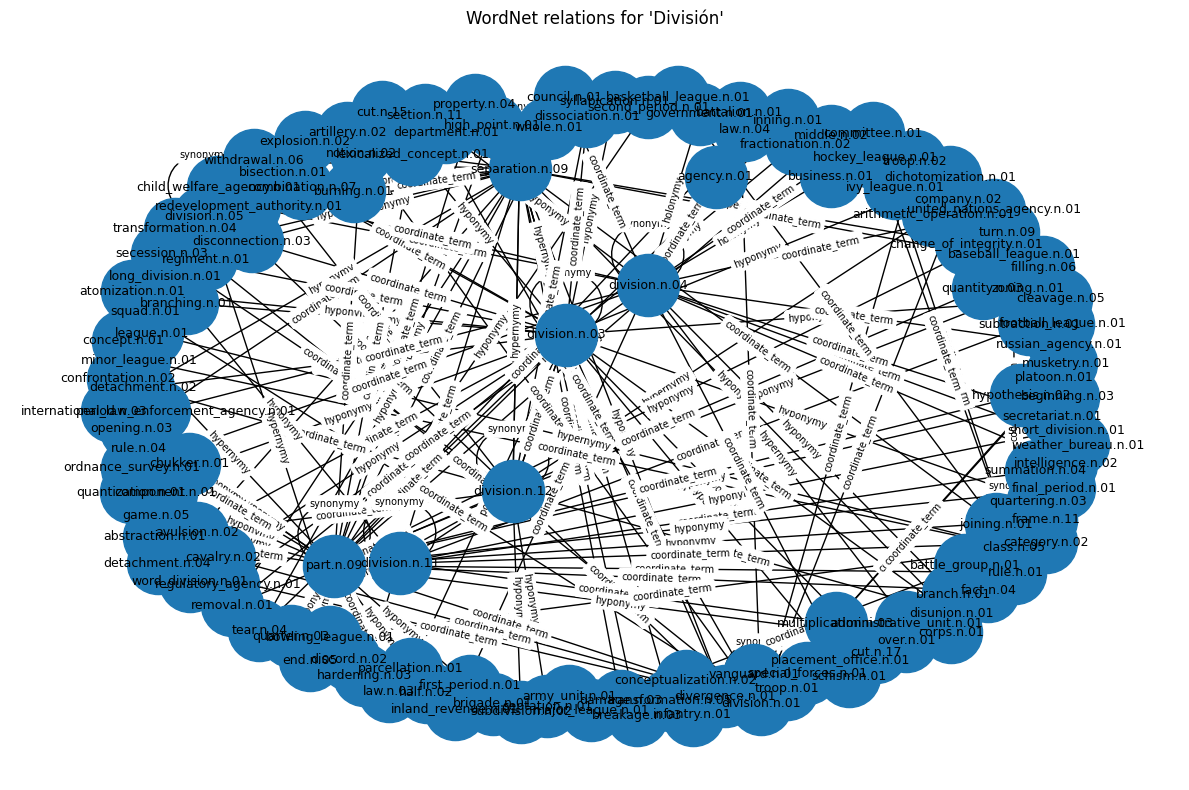

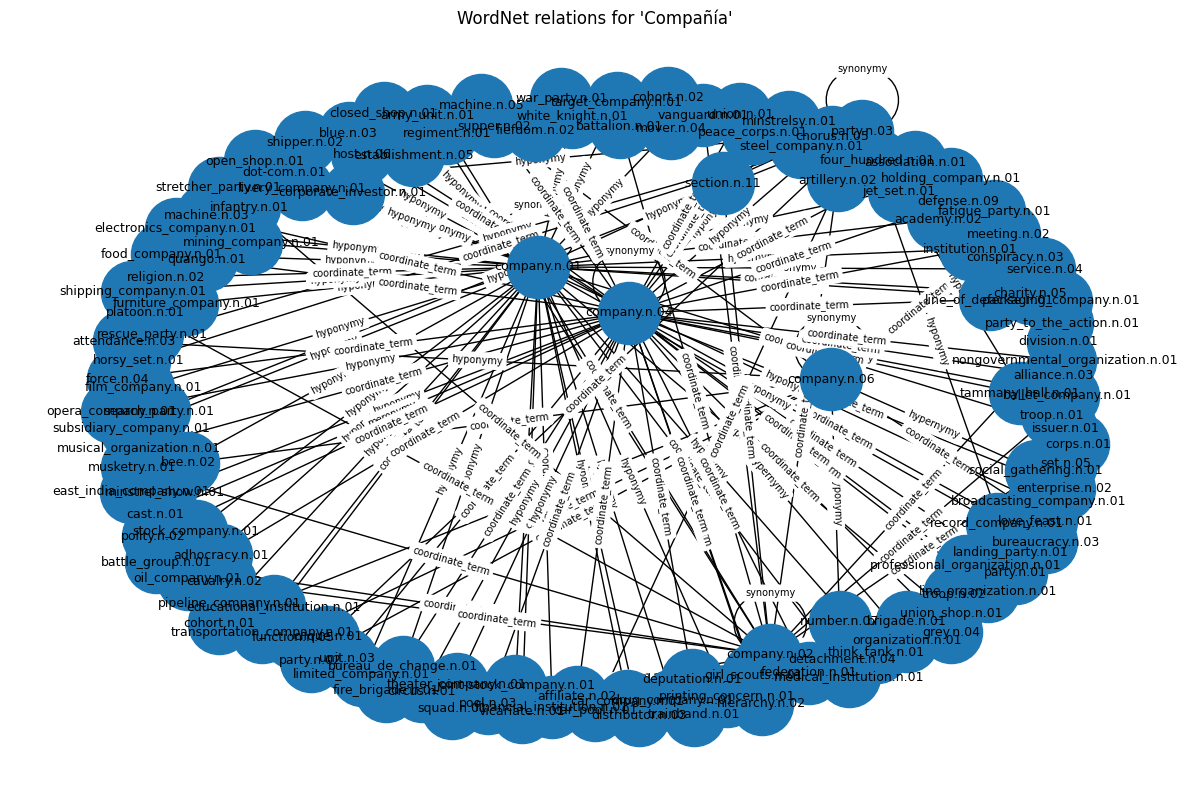

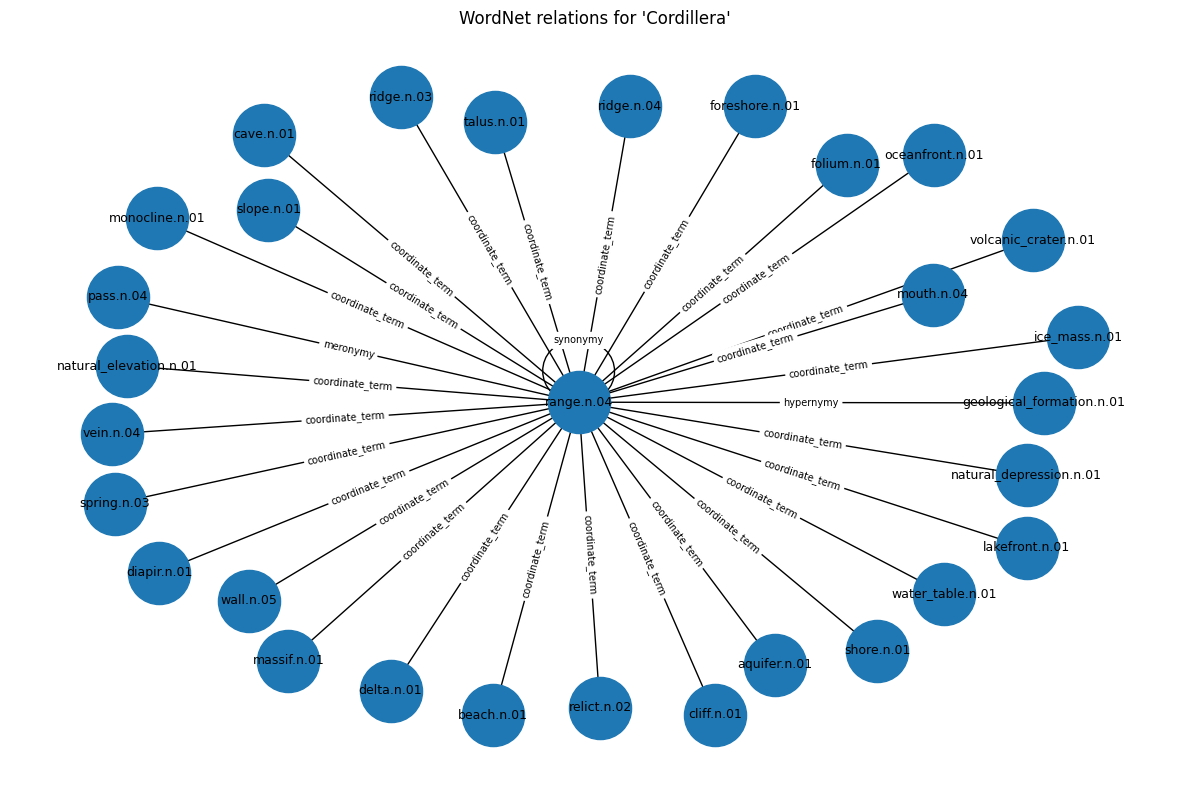

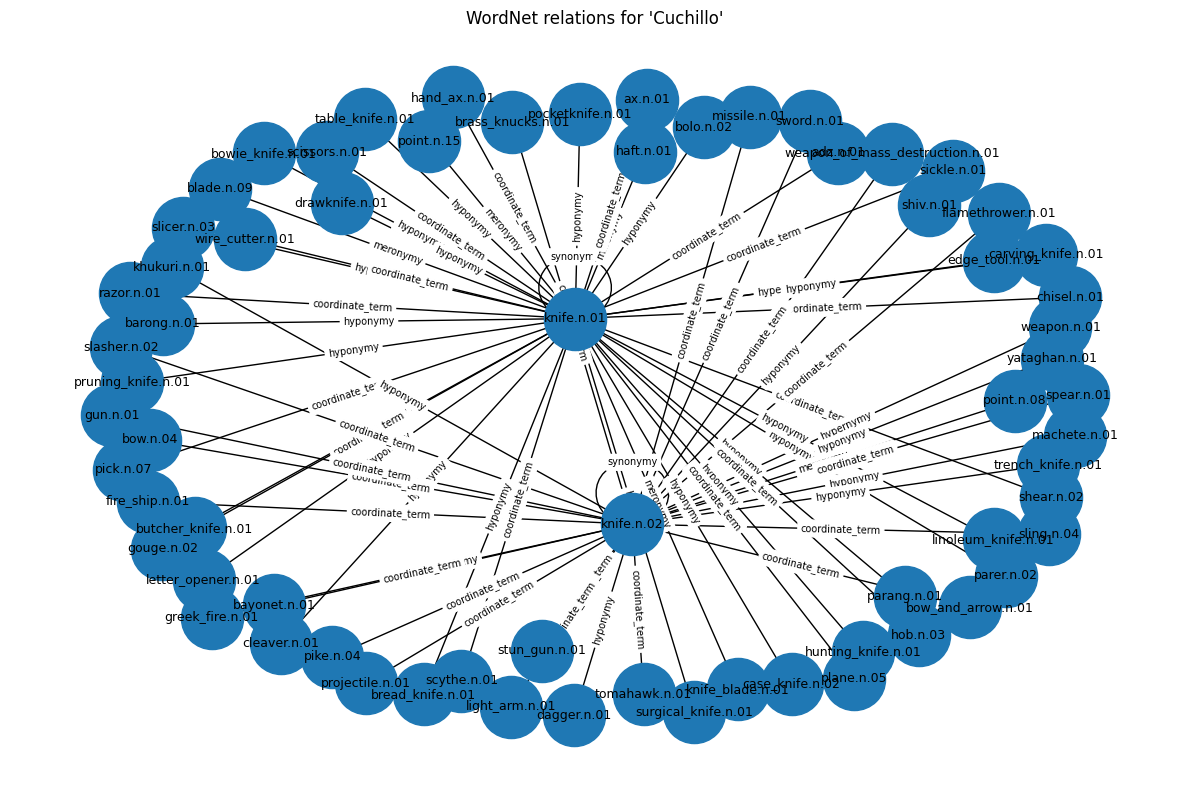

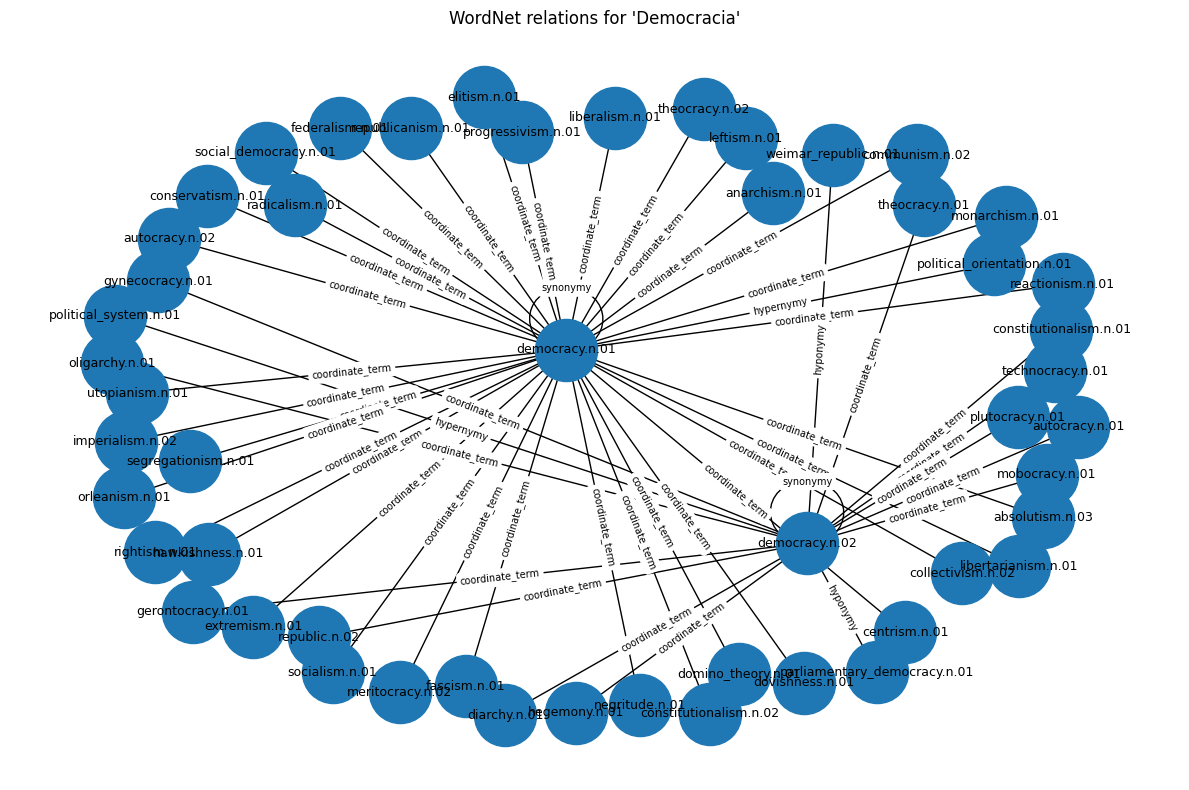

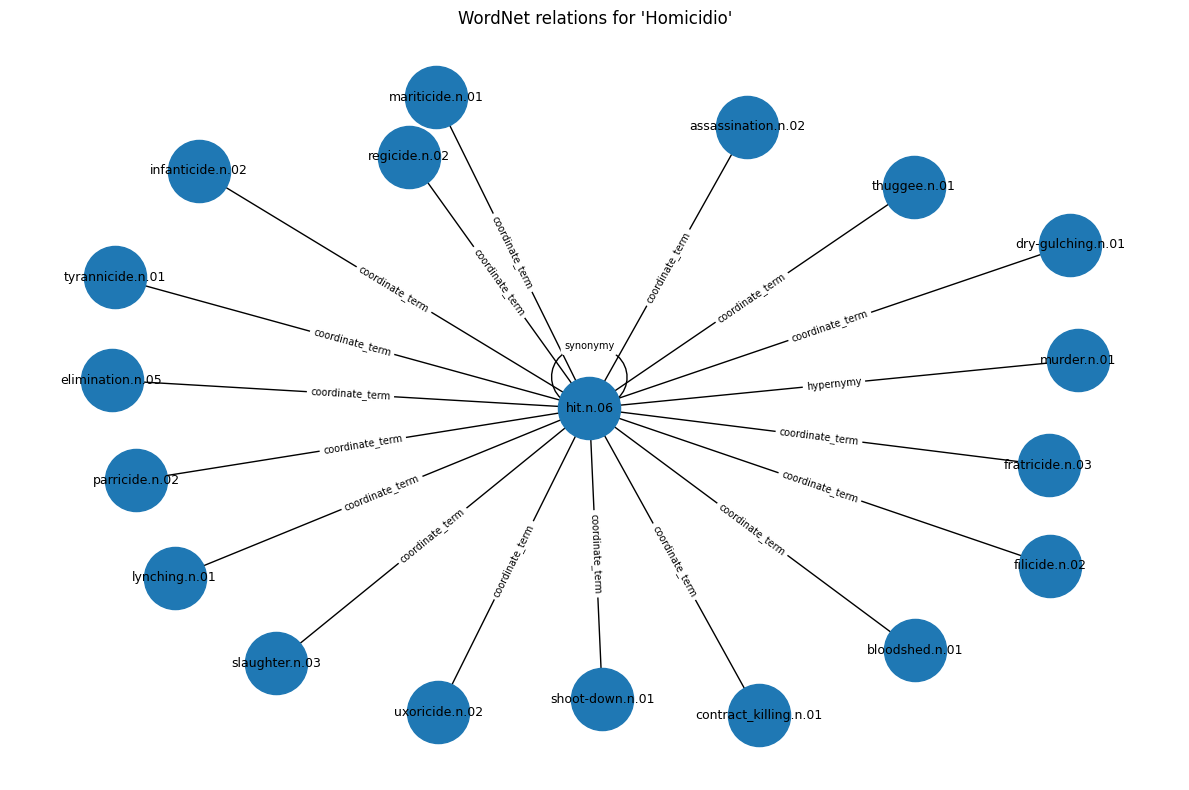

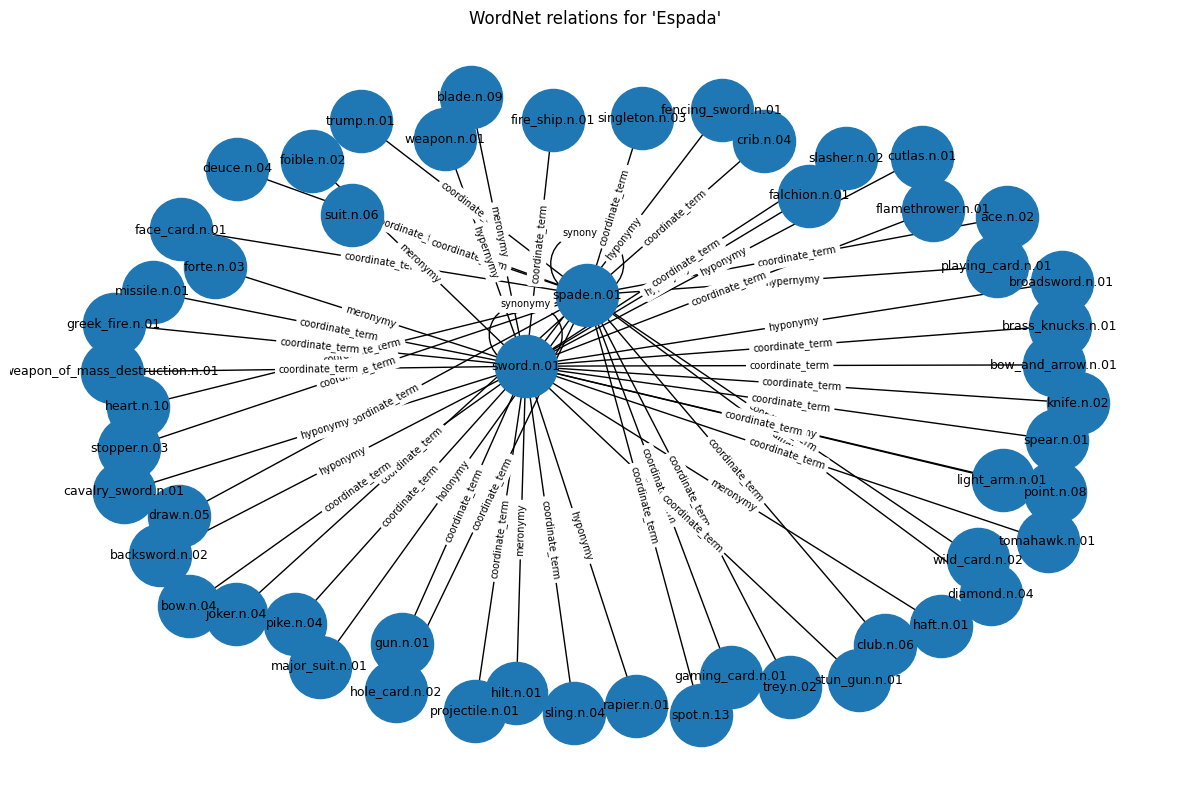

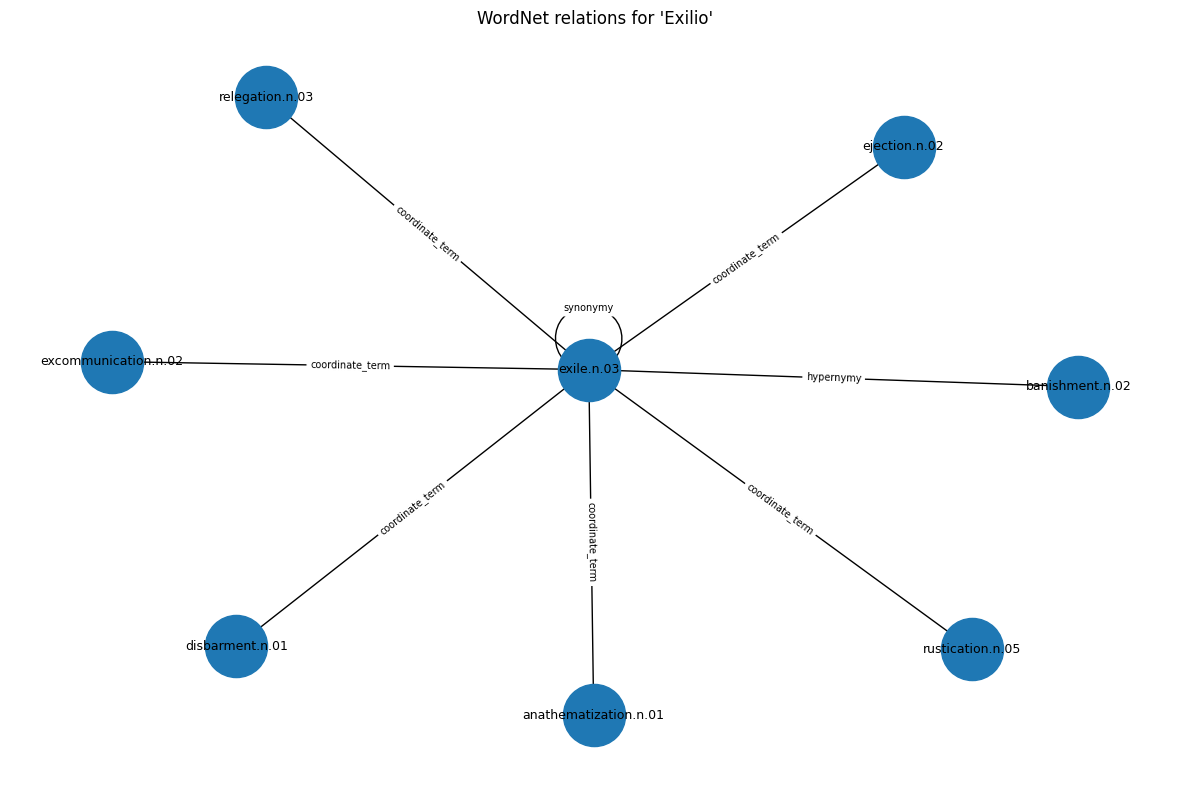

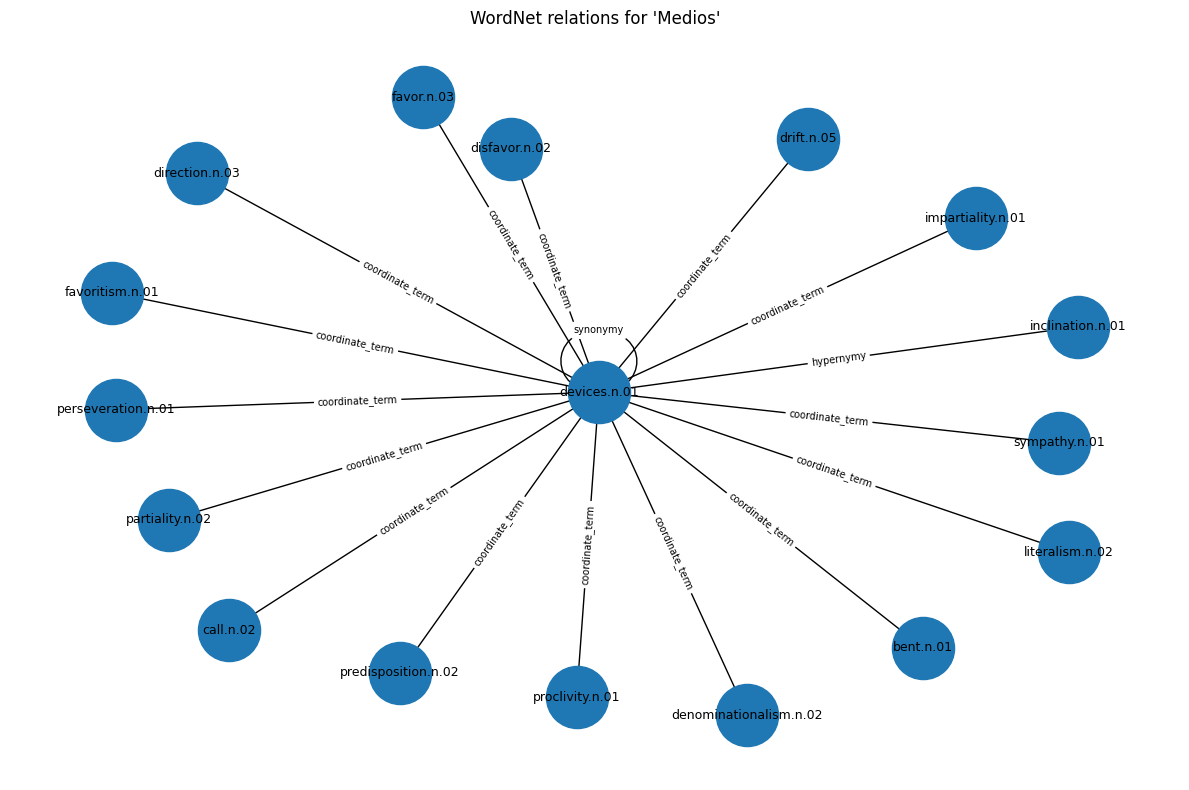

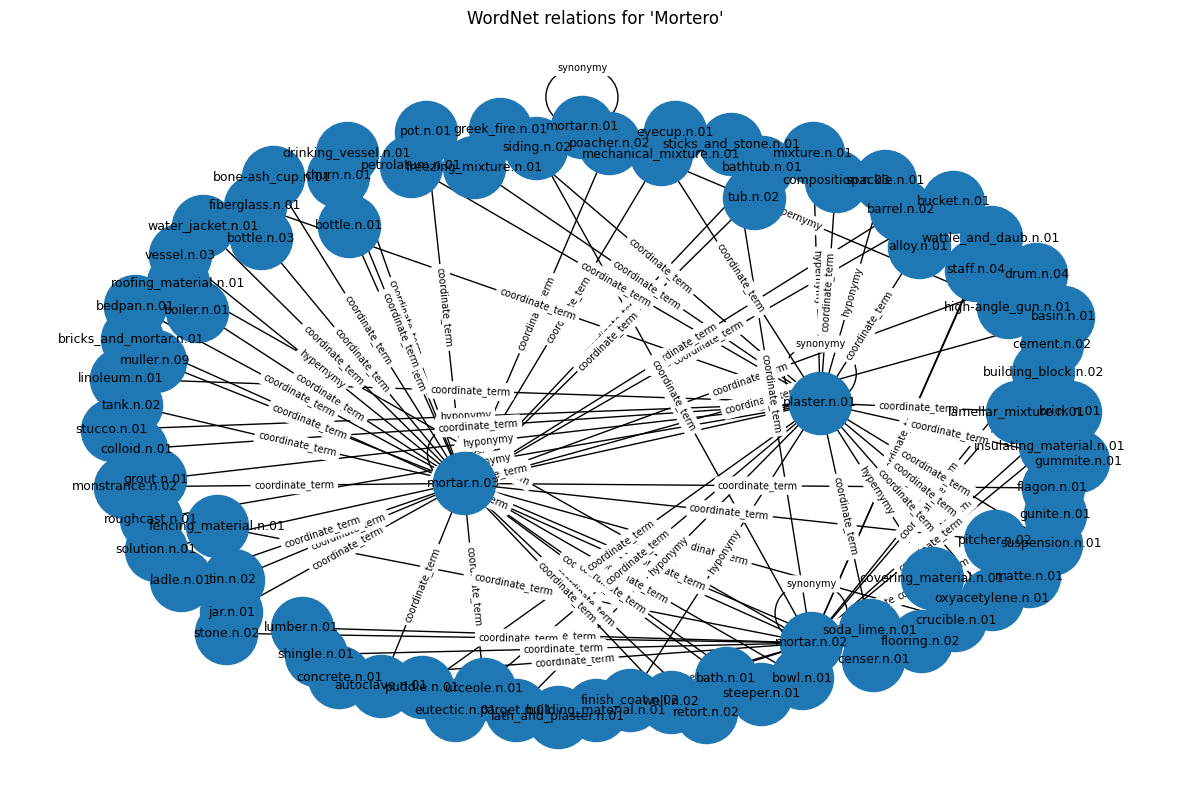

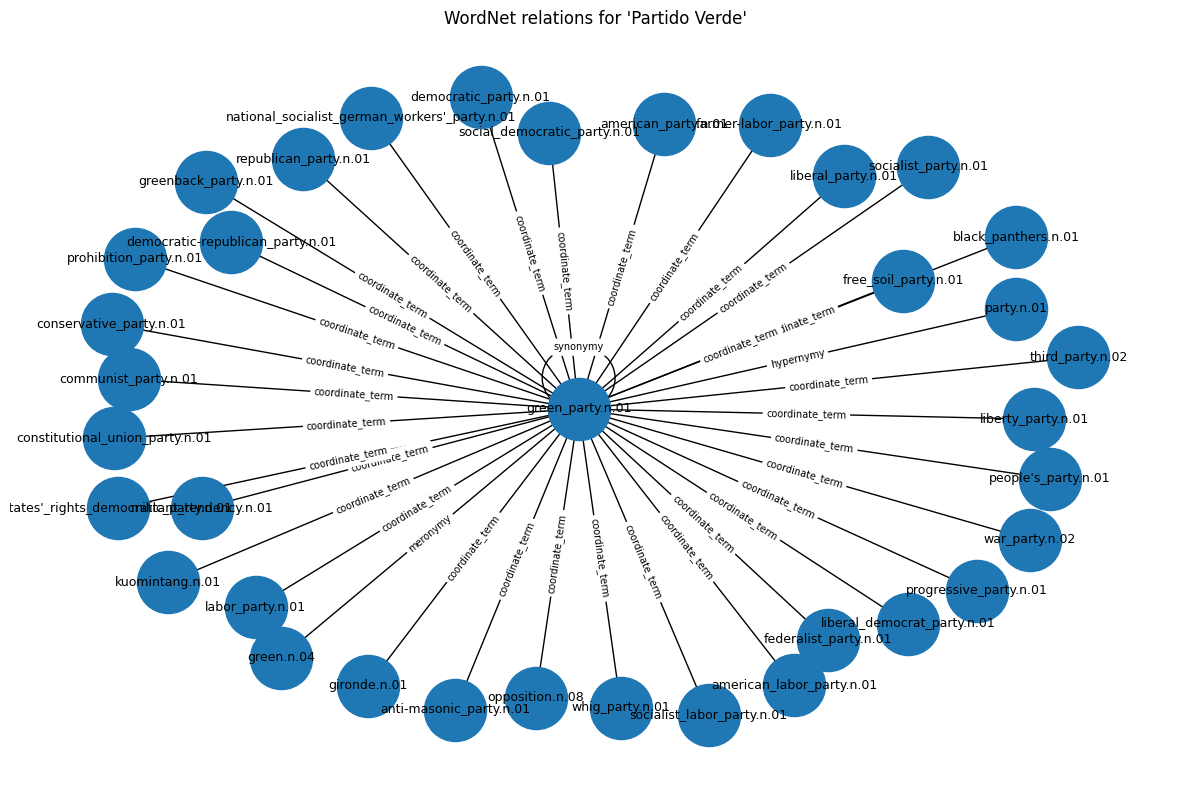

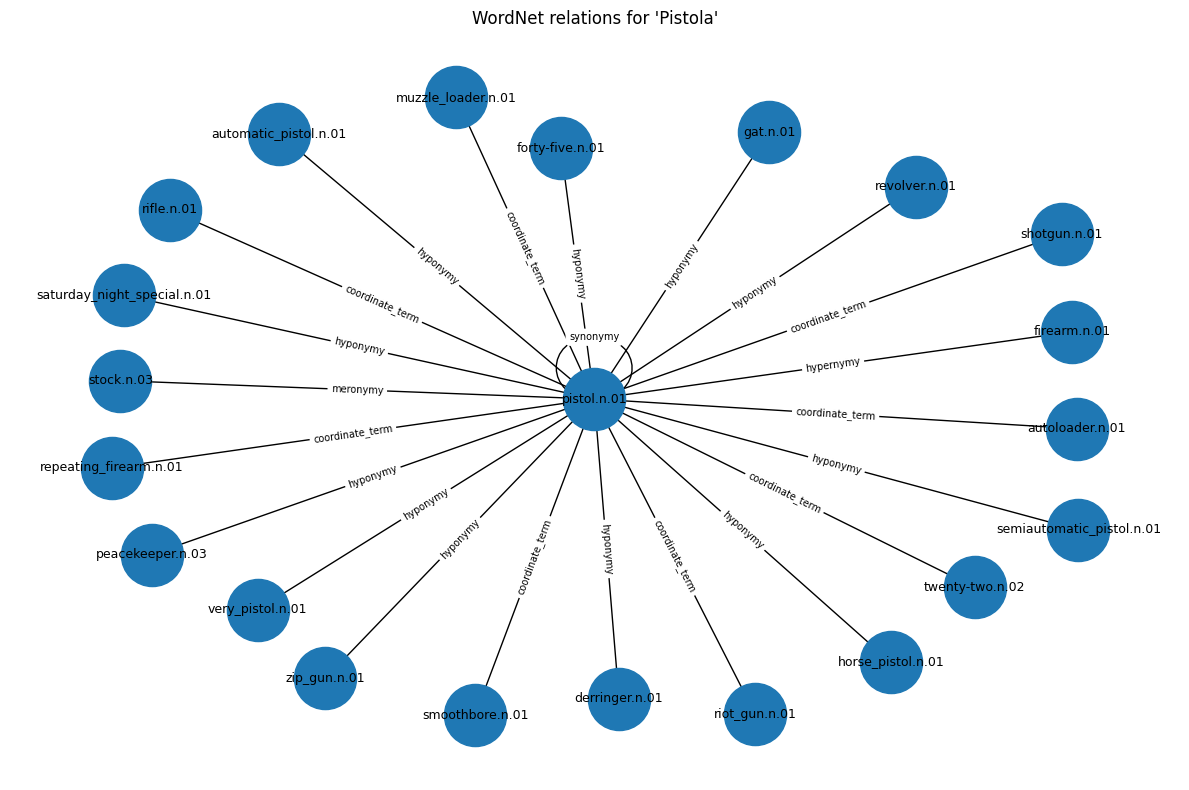

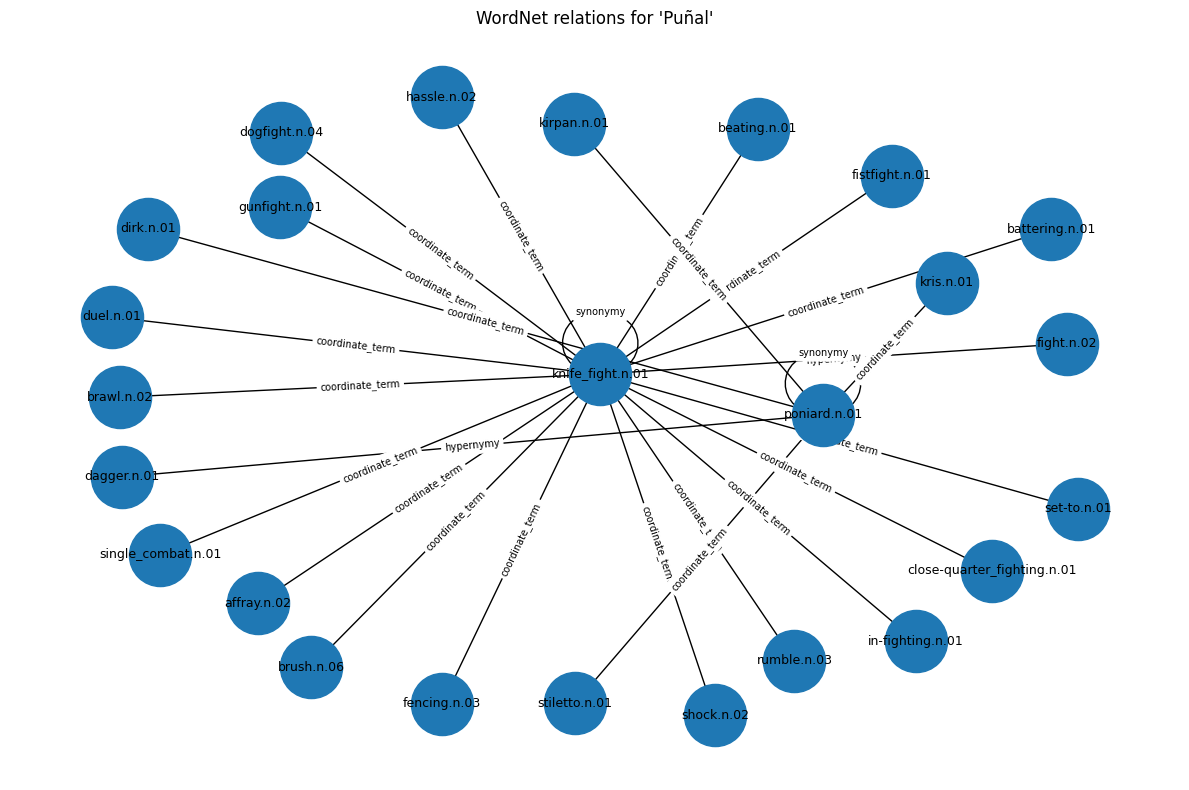

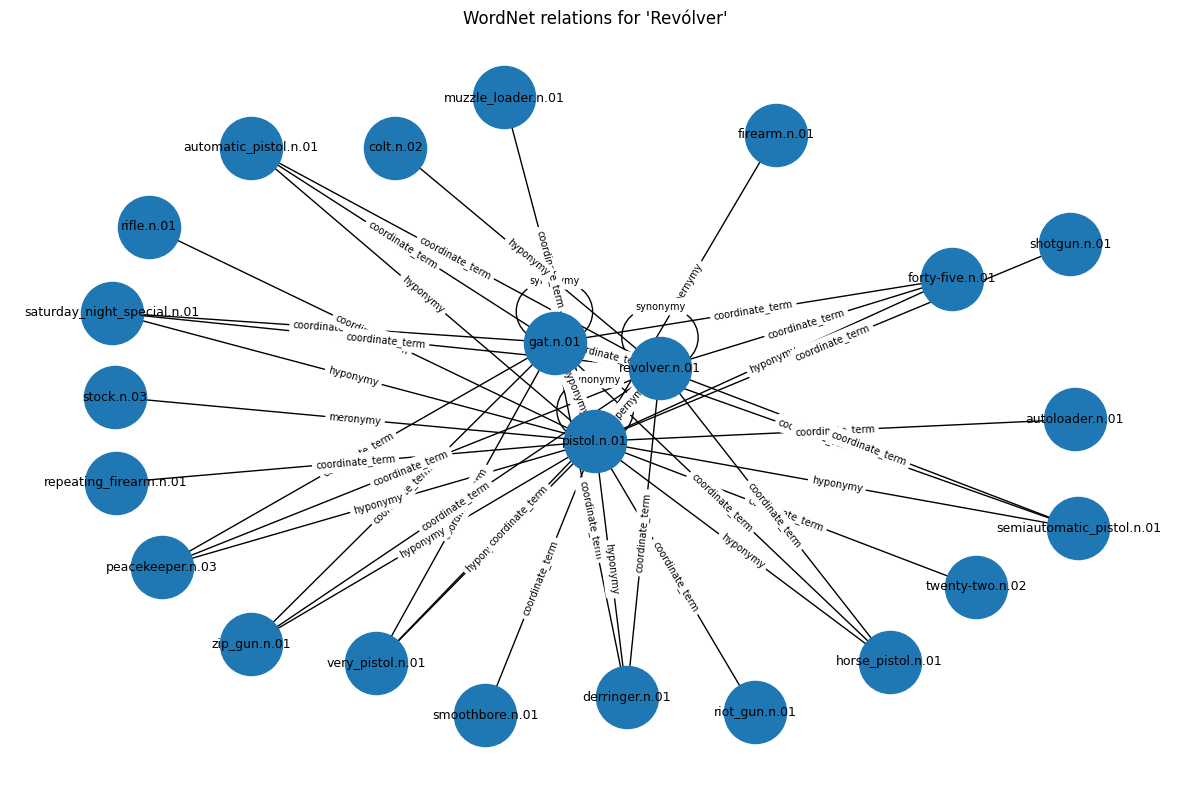

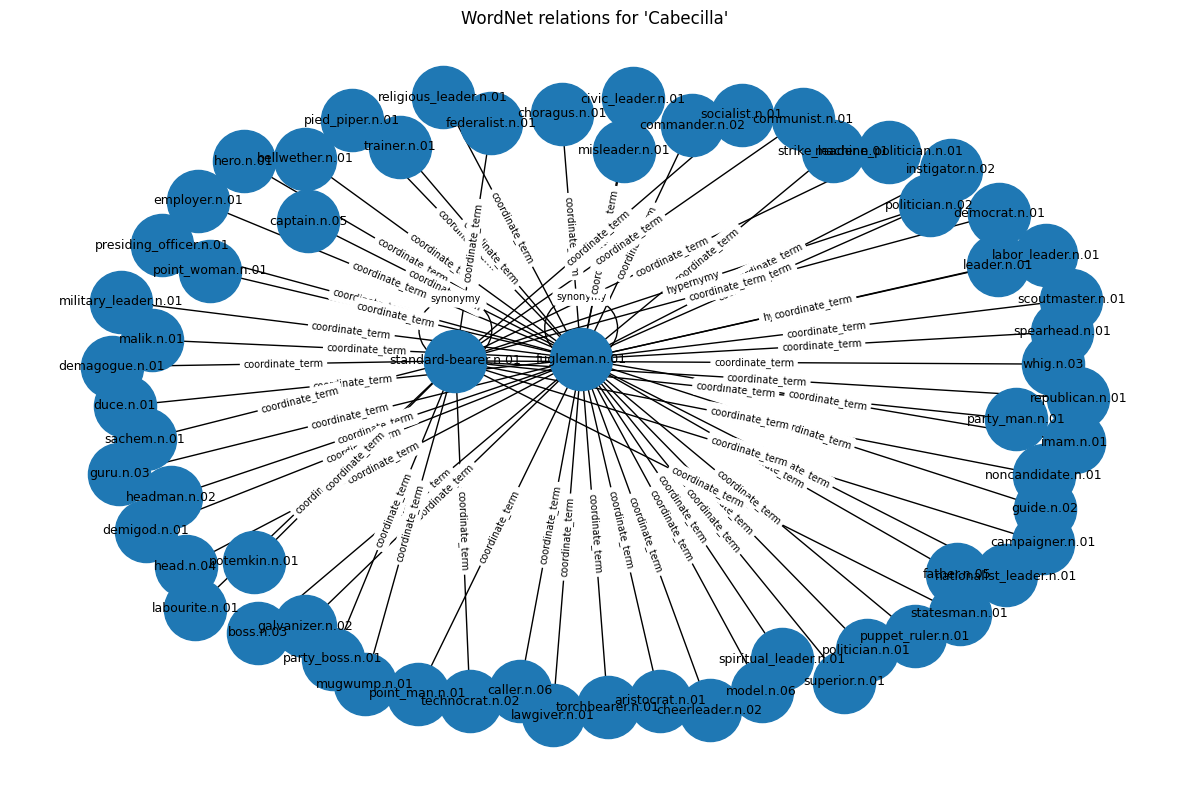

In [59]:
import networkx as nx
import matplotlib.pyplot as plt

# First 20 unique labels
labels = synsets_df["label"].drop_duplicates().head(20)

for label in labels:

    G = nx.DiGraph()

    # Get all rows associated with this label
    selected = synsets_df[
        synsets_df["label"] == label
    ]

    for _, row in selected.iterrows():

        source = row["synset"]

        # Source node
        G.add_node(
            source,
            node_type="source",
            label=row["label"]
        )

        # Relations
        for relation in row["relations"]:

            target = relation["target_synset"]
            relation_type = relation["relation"]

            G.add_node(
                target,
                node_type="target"
            )

            G.add_edge(
                source,
                target,
                relation=relation_type
            )

    # Skip concepts with no relations
    if G.number_of_edges() == 0:
        print(f"Skipping '{label}' — no relations")
        continue

    # -----------------------------
    # Plot
    # -----------------------------

    plt.figure(figsize=(12, 8))

    pos = nx.spring_layout(
        G,
        seed=42,
        k=2
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=2000
    )

    nx.draw_networkx_edges(
        G,
        pos,
        arrows=True,
        arrowsize=15
    )

    # Node labels
    nx.draw_networkx_labels(
        G,
        pos,
        font_size=9
    )

    # Relation labels
    edge_labels = nx.get_edge_attributes(
        G,
        "relation"
    )

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=7
    )

    plt.title(
        f"WordNet relations for '{label}'"
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()